In [2]:
!pip install geopandas pandas matplotlib contextily folium mapclassify libpysal esda statsmodels fiona

## 1. Library Imports and Path Definitions
Imports all required libraries for geospatial analysis, statistical testing, and visualization. Key packages include GeoPandas for vector data handling, libpysal and esda for spatial statistics, statsmodels for regression, folium for interactive mapping, and contextily for basemap tiles. The local GeoPackage path is defined here for reference, though the notebook loads from exported GeoJSON files to remain reproducible without the local file.

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import folium
import fiona

print("All libraries loaded successfully")

gpkg_path = "/mnt/e/Portfolio Files/nebraska-soil-project/ncss_labdata.gpkg"

All libraries loaded successfully


## 2. Load County Boundaries
Downloads Nebraska county boundaries directly from the U.S. Census Bureau TIGER/Line API as a GeoJSON and loads them into a GeoDataFrame. Using the API rather than a local shapefile keeps the project reproducible — anyone can clone the repo and run the notebook without additional downloads.

In [4]:
import geopandas as gpd
url = "https://SDMDataAccess.sc.egov.usda.gov/Tabular/post.rest"
# Load Nebraska county boundaries directly from Census TIGER
nebraska = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)

# Filter to Nebraska (state FIPS code is 31)
nebraska = nebraska[nebraska['STATEFP'] == '31']

print(f"Loaded {len(nebraska)} counties")
nebraska.head()

Loaded 93 counties


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,0500000US31039,Cuming,Cuming County,06,H1,G4020,NaN,NaN,NaN,A,1477563029,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55516 41.91587, -96.55515 41.914..."
3,31,109,00835876,31109,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,NaN,A,2169269688,22850324,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,NaN,NaN,NaN,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."
40,31,101,00835872,31101,0500000US31101,Keith,Keith County,06,H1,G4020,NaN,NaN,NaN,A,2750729944,123802447,+41.1942448,-101.6444493,"POLYGON ((-102.05546 41.29967, -102.05545 41.3..."
41,31,137,00835890,31137,0500000US31137,Phelps,Phelps County,06,H1,G4020,NaN,NaN,NaN,A,1397985736,1709313,+40.5163647,-099.4065568,"POLYGON ((-99.17949 40.52501, -99.17948 40.524..."


## 3. County Plot - Confirms Data loaded correctly
Check to confirm the county boundary data loaded correctly and that geometry is intact before querying soil data. 93 counties should be visible with no missing or distorted polygons.

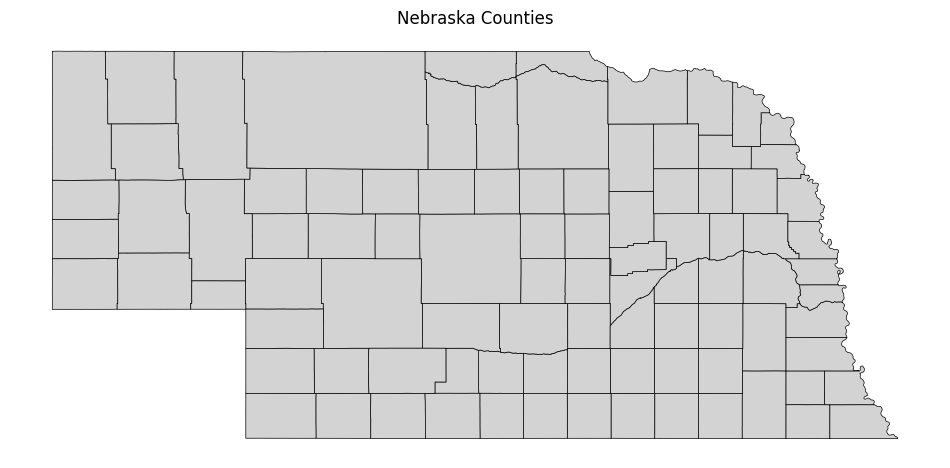

In [5]:
nebraska.plot(figsize=(12, 6), color='lightgrey', edgecolor='black', linewidth=0.5)
plt.title("Nebraska Counties")
plt.axis('off')
plt.show()

## 4. Define API Endpoint and Query Soil pH Data
Queries soil pH data from the USDA Web Soil Survey (SSURGO) via the Soil Data Access REST API. The query retrieves horizon-level pH measurements along with component percentage and horizon thickness, which are needed to compute depth-weighted averages. Data is returned as JSON and parsed into a DataFrame.

In [6]:
import requests
import json

url = "https://SDMDataAccess.sc.egov.usda.gov/Tabular/post.rest"

query_ph = """SELECT l.areasymbol, l.areaname, mu.musym, mu.muname, 
           co.comppct_r, hz.ph1to1h2o_r
           FROM legend l
           JOIN mapunit mu ON mu.lkey = l.lkey
           JOIN component co ON co.mukey = mu.mukey
           JOIN chorizon hz ON hz.cokey = co.cokey
           WHERE l.areasymbol LIKE 'NE%'
           AND hz.ph1to1h2o_r IS NOT NULL"""

payload = {"query": query_ph, "format": "json+columnname"}
response = requests.post(url, data=payload)

data = response.json()
rows = data['Table']
headers = rows[0]
df = pd.DataFrame(rows[1:], columns=headers)
df['ph1to1h2o_r'] = pd.to_numeric(df['ph1to1h2o_r'])

print(f"Loaded {len(df)} soil records")
df.head()

Loaded 77328 soil records


,areasymbol,areaname,musym,muname,comppct_r,ph1to1h2o_r
0,NE123,"Morrill County, Nebraska",5968,"Jayem fine sandy loam, 9 to 20 percent slopes",100,7.2
1,NE123,"Morrill County, Nebraska",5968,"Jayem fine sandy loam, 9 to 20 percent slopes",100,7.2
2,NE123,"Morrill County, Nebraska",5968,"Jayem fine sandy loam, 9 to 20 percent slopes",100,7.2
3,NE123,"Morrill County, Nebraska",5968,"Jayem fine sandy loam, 9 to 20 percent slopes",100,7.2
4,NE031,"Cherry County, Nebraska",5267,"Tuthill fine sandy loam, 6 to 9 percent slopes",90,7.9


## 5. Calculate Weighted Average Soil pH by County
Computes a component-weighted average pH for each county. Raw SSURGO data contains multiple soil components per map unit at varying coverage percentages — a simple mean would overrepresent minor soil components. The weighted average uses component percentage (`comppct_r`) as the weight, producing a single representative pH value per county that reflects the actual composition of soils on the landscape.

In [7]:
# Extract county name and calculate weighted average pH per county
df['comppct_r'] = pd.to_numeric(df['comppct_r'])

# Pull clean county name from areaname (remove ", Nebraska")
df['county'] = df['areaname'].str.replace(', Nebraska', '', regex=False).str.strip()

# Weighted average pH by county
county_ph = df.groupby('county').apply(
    lambda x: (x['ph1to1h2o_r'] * x['comppct_r']).sum() / x['comppct_r'].sum()
).reset_index()

county_ph.columns = ['county', 'avg_ph']
county_ph = county_ph.sort_values('avg_ph', ascending=False)

print(f"{len(county_ph)} counties with pH data")
county_ph.head(10)

93 counties with pH data


,county,avg_ph
28,Dundy County,7.794262
78,Scotts Bluff County,7.741405
43,Hitchcock County,7.737147
72,Red Willow County,7.629928
22,Dawes County,7.621980
82,Sioux County,7.607287
42,Hayes County,7.586606
3,Banner County,7.556212
32,Furnas County,7.541582
14,Chase County,7.533247


## 6. Merge pH Data onto County Boundaries
Joins the computed pH values onto the county GeoDataFrame by county name. 92 of 93 Nebraska counties returned pH data from SSURGO; one county had no matching records and is excluded from pH analysis.

In [8]:
# Standardize county names for joining
nebraska['county'] = nebraska['NAME'] + ' County'

# Merge pH data onto county shapes
nebraska_ph = nebraska.merge(county_ph, on='county', how='left')

print(f"Counties with pH data: {nebraska_ph['avg_ph'].notna().sum()}")
print(f"Counties missing pH data: {nebraska_ph['avg_ph'].isna().sum()}")
nebraska_ph[['county', 'avg_ph']].head(10)

Counties with pH data: 92
Counties missing pH data: 1


,county,avg_ph
0,Cuming County,7.205059
1,Lancaster County,6.877413
2,Nuckolls County,7.117788
3,Keith County,7.458775
4,Phelps County,7.294694
5,Webster County,7.348759
6,Dakota County,7.470700
7,Boyd County,7.179913
8,Thomas County,6.730216
9,Holt County,6.855689


## 7. Plot Soil pH by County
Choropleth map of weighted average soil pH across Nebraska counties using a continuous diverging color scale. The map reveals a clear east-west gradient: counties in the western Panhandle tend toward alkaline soils (pH > 7.5), while eastern counties trend more neutral to mildly acidic — a pattern driven by differences in precipitation and carbonate leaching.

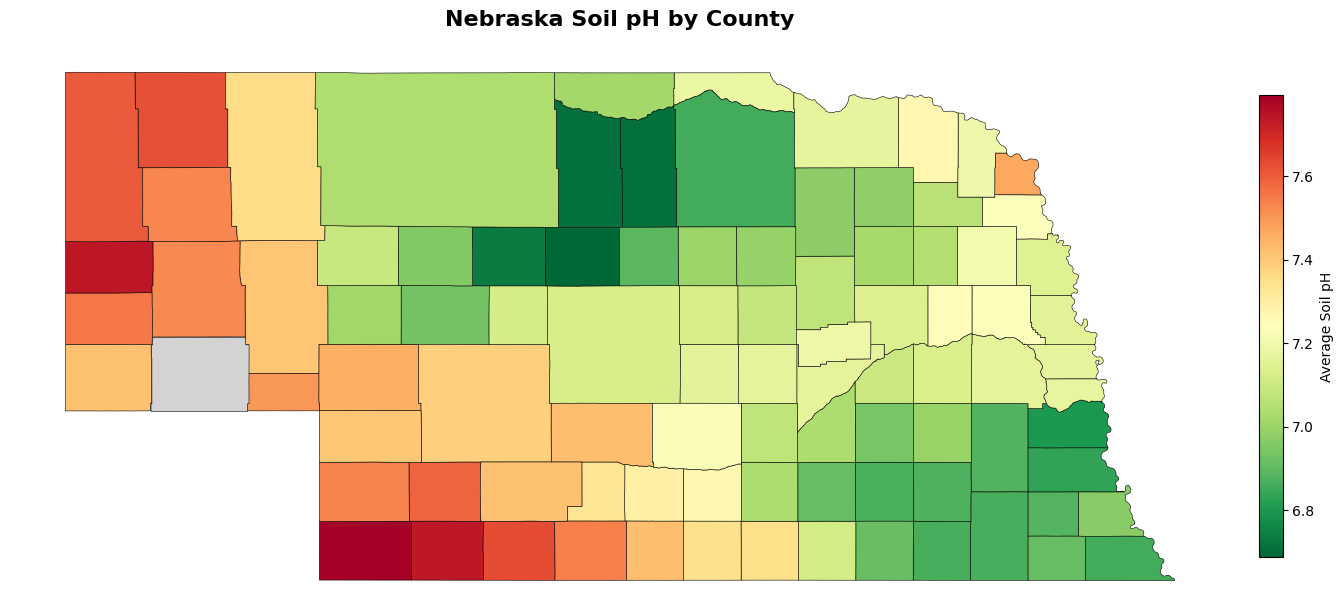

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={
        'label': 'Average Soil pH',
       # 'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

ax.set_title('Nebraska Soil pH by County', fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('nebraska_soil_ph.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Query Organic Matter
Queries soil organic matter (OM) content from the same USDA SSURGO API endpoint, also pulling pH values from this response for cross-referencing. Organic matter — decomposed plant and animal material — is a key indicator of soil health and agricultural productivity. The same component-weighting approach used for pH will be applied to OM.

In [10]:
query_p = """SELECT l.areasymbol, l.areaname, 
           co.comppct_r, hz.ph1to1h2o_r, hz.om_r
           FROM legend l
           JOIN mapunit mu ON mu.lkey = l.lkey
           JOIN component co ON co.mukey = mu.mukey
           JOIN chorizon hz ON hz.cokey = co.cokey
           WHERE l.areasymbol LIKE 'NE%'
           AND hz.om_r IS NOT NULL"""

payload_p = {"query": query_p, "format": "json+columnname"}

response_p = requests.post(url, data=payload_p)
print(response_p.status_code)
print(response_p.text[:500])

200
{"Table":[["areasymbol","areaname","comppct_r","ph1to1h2o_r","om_r"],["NE103","Keya Paha County, Nebraska","100","7","2"],["NE103","Keya Paha County, Nebraska","100","7.5","1"],["NE103","Keya Paha County, Nebraska","100",null,"0.25"],["NE107","Knox County, Nebraska","3","7.3","0.25"],["NE107","Knox County, Nebraska","3","7.9","0.5"],["NE107","Knox County, Nebraska","3","7.9","0.75"],["NE107","Knox County, Nebraska","3","7.5","3"],["NE107","Knox County, Nebraska","3","6.5","0.25"],["NE107","Knox 


## 9. Parse and Aggregate Organic Matter Data
Parses the raw OM JSON response and applies the same weighted averaging calculation used for pH. Results are aggregated to the county level, yielding a single representative organic matter percentage per county.

In [11]:
# Parse organic matter response
data_p = response_p.json()
rows_p = data_p['Table']
headers_p = rows_p[0]
df_p = pd.DataFrame(rows_p[1:], columns=headers_p)

# Convert to numeric
df_p['comppct_r'] = pd.to_numeric(df_p['comppct_r'])
df_p['om_r'] = pd.to_numeric(df_p['om_r'])

# Clean county name
df_p['county'] = df_p['areaname'].str.replace(', Nebraska', '', regex=False).str.strip()

# Weighted average organic matter by county
county_om = df_p.groupby('county').apply(
    lambda x: (x['om_r'] * x['comppct_r']).sum() / x['comppct_r'].sum()
).reset_index()
county_om.columns = ['county', 'avg_om']

# Add sample counts for both datasets
ph_counts = df.groupby('county').size().reset_index(name='ph_count')
om_counts = df_p.groupby('county').size().reset_index(name='om_count')
county_ph_full = county_ph.merge(ph_counts, on='county')
county_om_full = county_om.merge(om_counts, on='county')

print(f"{len(county_om_full)} counties with organic matter data")
county_om_full.sort_values('avg_om', ascending=False).head(10)

93 counties with organic matter data


,county,avg_om,om_count
2,Arthur County,8.614317,521
45,Hooker County,6.549674,564
37,Grant County,6.232505,611
59,McPherson County,5.192270,528
15,Cherry County,4.001681,1307
34,Garden County,2.365315,848
80,Sheridan County,2.279544,1399
91,Wheeler County,2.132966,653
6,Box Butte County,2.030089,1164
92,York County,2.024610,477


## 10. Merge OM onto County Boundaries and Create Combined Dataset
Merges organic matter values onto the county GeoDataFrame alongside the previously joined pH data, creating a single combined dataset for joint analysis and visualization. Counties missing OM data are flagged for transparency.

In [12]:
# Merge pH and OM onto county shapes
nebraska_om = nebraska.merge(county_om_full, on='county', how='left')
nebraska_combined = nebraska_ph.merge(
    nebraska_om[['county', 'avg_om']], 
    on='county', 
    how='left'
)

## 11. Two-Panel Soil Chemistry Map
Side-by-side choropleth maps displaying soil pH (continuous scale) and organic matter (natural breaks, k=8) across Nebraska counties. Displaying both variables together allows visual comparison of their spatial distributions. The Sandhills region in central Nebraska stands out clearly in the OM panel — several counties there average well above 5% organic matter due to native prairie cover and minimal tillage disturbance.

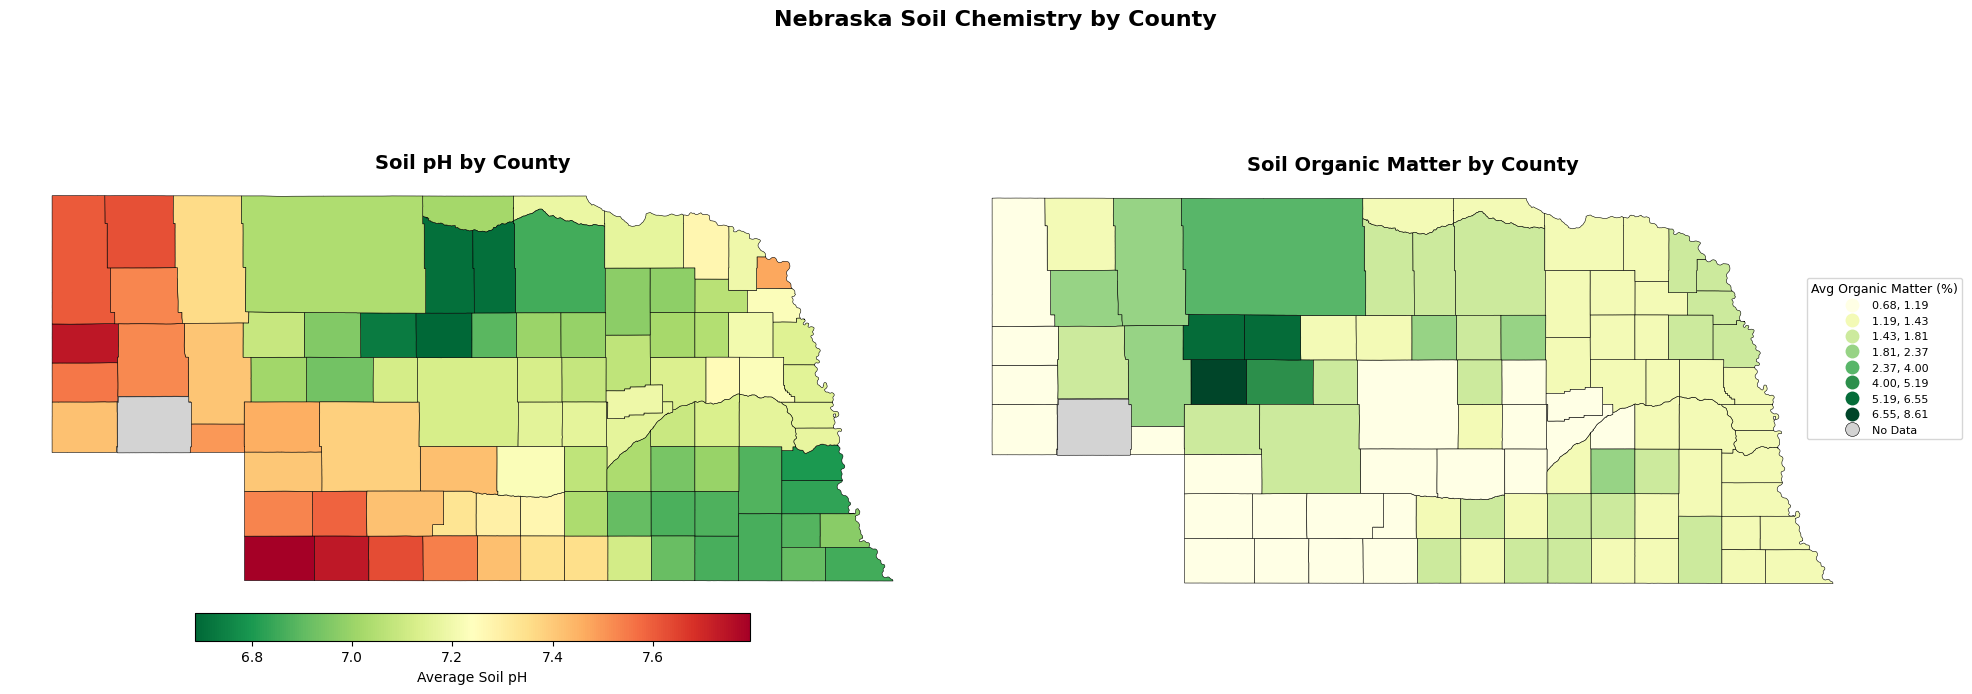

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Average Soil pH', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_combined.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='natural_breaks',
    k=8,
    legend=True,
    legend_kwds={
        'title': 'Avg Organic Matter (%)',
        'loc': 'upper left',
        'bbox_to_anchor': (0.92, 0.78),
        'fontsize': 8,
        'title_fontsize': 9,
        'frameon': True
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. MLRA Query, Parse into GeoDataFrame
Queries Major Land Resource Area (MLRA) boundaries from the USDA Natural Resources Conservation Service (NRCS). MLRAs are USDA-defined regions of similar soils, climate, water, and land use — they provide a meaningful ecological framework for grouping Nebraska counties beyond arbitrary political boundaries. Nebraska falls within Land Resource Regions F, G, H, and M, covering 16 distinct MLRAs.

In [14]:
# Fetch MLRA data including eastern Nebraska (LRR M)
mlra_url = "https://services.arcgis.com/SXbDpmb7xQkk44JV/arcgis/rest/services/MLRA_52/FeatureServer/0/query"

params = {
    "where": "LRRSYM IN ('F', 'G', 'H', 'M')",
    "outFields": "MLRARSYM,MLRA_NAME,LRRSYM",
    "f": "geojson",
    "outSR": "4326"
}

response_mlra = requests.get(mlra_url, params=params)

mlra = gpd.GeoDataFrame.from_features(
    json.loads(response_mlra.text)['features'],
    crs='EPSG:4326'
)

# Dissolve Nebraska counties into state boundary and clip MLRAs
nebraska_boundary = nebraska.dissolve().to_crs('EPSG:4326')
mlra_ne = gpd.clip(mlra, nebraska_boundary)

print(f"{len(mlra_ne)} MLRAs intersecting Nebraska")
print(mlra_ne['MLRA_NAME'].unique())

15 MLRAs intersecting Nebraska
<StringArray>
[                   'Rolling Plains and Breaks',
                         'Central Loess Plains',
                       'Central High Tableland',
           'Central High Plains, Northern Part',
 'Mixed Sandy and Silty Tableland and Badlands',
               'Central Kansas Sandstone Hills',
        'Nebraska and Kansas Loess-Drift Hills',
           'Iowa and Missouri Deep Loess Hills',
                                'Loess Uplands',
                 'Central Nebraska Loess Hills',
                          'Nebraska Sand Hills',
             'Dakota-Nebraska Eroded Tableland',
         'Southern Rolling Pierre Shale Plains',
              'Southern Black Glaciated Plains',
                          'Pierre Shale Plains']
Length: 15, dtype: str


## 13. Dissolve, Clip to Nebraska Counties
Re-runs the state boundary dissolve and MLRA clip explicitly as a standalone step for clarity. The clipped MLRA layer (`mlra_ne`) is used in all subsequent mapping and spatial overlay operations.

In [15]:
# Dissolve Nebraska counties into a single state boundary
nebraska_boundary = nebraska.dissolve().to_crs('EPSG:4326')

# Clip MLRAs to Nebraska
mlra_ne = gpd.clip(mlra, nebraska_boundary)

print(f"{len(mlra_ne)} MLRAs intersecting Nebraska")
print(mlra_ne['MLRA_NAME'].unique())

15 MLRAs intersecting Nebraska
<StringArray>
[                   'Rolling Plains and Breaks',
                         'Central Loess Plains',
                       'Central High Tableland',
           'Central High Plains, Northern Part',
 'Mixed Sandy and Silty Tableland and Badlands',
               'Central Kansas Sandstone Hills',
        'Nebraska and Kansas Loess-Drift Hills',
           'Iowa and Missouri Deep Loess Hills',
                                'Loess Uplands',
                 'Central Nebraska Loess Hills',
                          'Nebraska Sand Hills',
             'Dakota-Nebraska Eroded Tableland',
         'Southern Rolling Pierre Shale Plains',
              'Southern Black Glaciated Plains',
                          'Pierre Shale Plains']
Length: 15, dtype: str


## 14. MLRA Reference Map
Reference map showing the 16 MLRAs present in Nebraska, color-coded and labeled. This map contextualizes subsequent ANOVA and Tukey HSD results by showing which regions are geographically adjacent — spatially proximate MLRAs with similar soil chemistry are expected to show fewer significant pairwise differences.

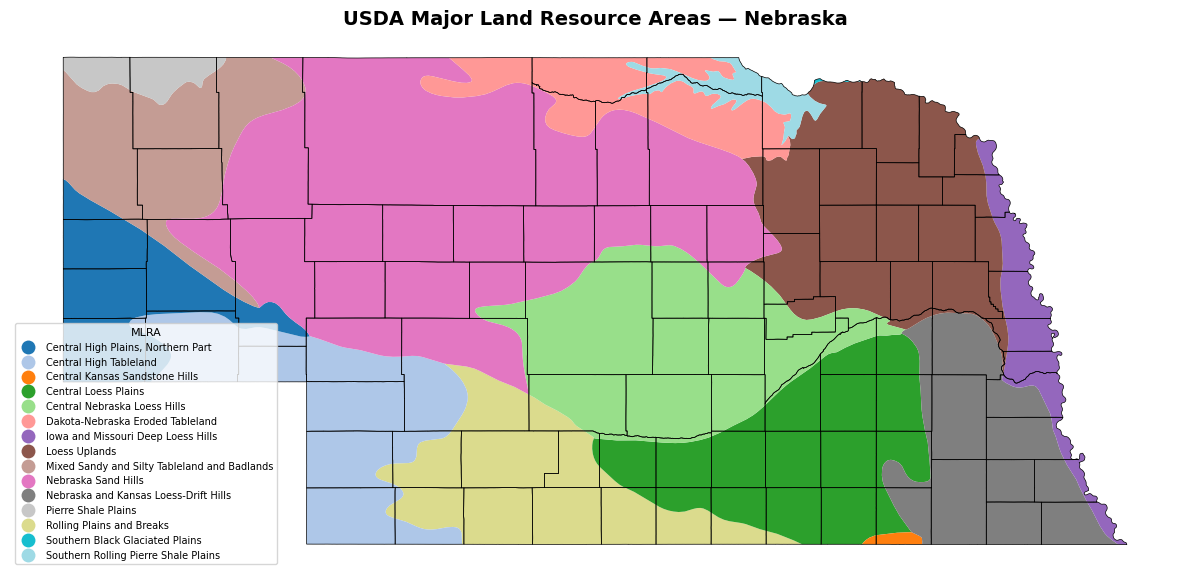

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

mlra_ne.plot(
    column='MLRA_NAME',
    ax=ax,
    cmap='tab20',
    edgecolor='none',
    legend=True,
    legend_kwds={'loc': 'lower left', 'fontsize': 7, 'title': 'MLRA', 'title_fontsize': 8}
)

nebraska.to_crs('EPSG:4326').plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=0.5
)

ax.set_title('USDA Major Land Resource Areas — Nebraska', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 15. Assign Dominant MLRA to Each County
Performs an area-weighted spatial overlay to assign each county its dominant MLRA — the one covering the greatest share of that county's area. Some counties span multiple MLRAs; using the dominant MLRA is a reasonable simplification for county-level grouping in ANOVA analysis.

In [17]:
# Merge pH and OM data together into one geodataframe
nebraska_combined = nebraska_ph.merge(
    nebraska_om[['county', 'avg_om']], 
    on='county', 
    how='left'
)

# Reproject both to projected CRS
nebraska_combined_proj = nebraska_combined.to_crs('EPSG:32614')
mlra_ne_proj = mlra_ne.to_crs('EPSG:32614')

# Overlay to get intersection areas
county_mlra_overlay = gpd.overlay(
    nebraska_combined_proj[['county', 'avg_ph', 'avg_om', 'geometry']], 
    mlra_ne_proj[['MLRA_NAME', 'geometry']], 
    how='intersection'
)

# Calculate area and keep dominant MLRA per county
county_mlra_overlay['area'] = county_mlra_overlay.geometry.area
dominant_mlra = county_mlra_overlay.loc[county_mlra_overlay.groupby('county')['area'].idxmax()]
dominant_mlra = dominant_mlra[['county', 'MLRA_NAME', 'avg_ph', 'avg_om']].reset_index(drop=True)

print(f"Counties with dominant MLRA assigned: {len(dominant_mlra)}")
dominant_mlra.head(10)

Counties with dominant MLRA assigned: 93


,county,MLRA_NAME,avg_ph,avg_om
0,Adams County,Central Loess Plains,7.034459,1.310714
1,Antelope County,Loess Uplands,6.976148,1.337979
2,Arthur County,Nebraska Sand Hills,7.011766,8.614317
3,Banner County,"Central High Plains, Northern Part",7.556212,1.077763
4,Blaine County,Nebraska Sand Hills,6.686396,1.374729
5,Boone County,Loess Uplands,7.072675,1.234803
6,Box Butte County,Mixed Sandy and Silty Tableland and Badlands,7.527504,2.030089
7,Boyd County,Southern Rolling Pierre Shale Plains,7.179913,1.218084
8,Brown County,Nebraska Sand Hills,6.707081,1.663342
9,Buffalo County,Central Nebraska Loess Hills,7.225797,1.100427


## 16. Correlation Analysis - pH vs Organic Matter
Computes the Pearson correlation coefficient between county-level weighted average pH and organic matter. The result (r = -0.20, p = 0.056) suggests a weak negative relationship — counties with higher pH tend toward slightly lower organic matter — but the association falls just short of conventional statistical significance. This borderline result warrants caution: county-level aggregation and strong spatial autocorrelation in both variables can inflate or obscure true correlations.

In [18]:
from scipy import stats

# Pearson correlation between pH and organic matter
r, p_value = stats.pearsonr(
    dominant_mlra['avg_ph'].dropna(),
    dominant_mlra['avg_om'].dropna()
)

print(f"Pearson r: {r:.3f}")
print(f"p-value: {p_value:.4f}")

Pearson r: -0.200
p-value: 0.0562


## 17. Generate Scatter Plots
Two-panel scatter plot of pH vs. organic matter: one showing all 92 counties with a regression line, and a zoomed version excluding the high-OM Sandhills outliers for a cleaner view of the main cluster. The Sandhills counties (particularly Arthur County at ~8.6% OM) exert significant leverage on the regression and are worth examining separately.

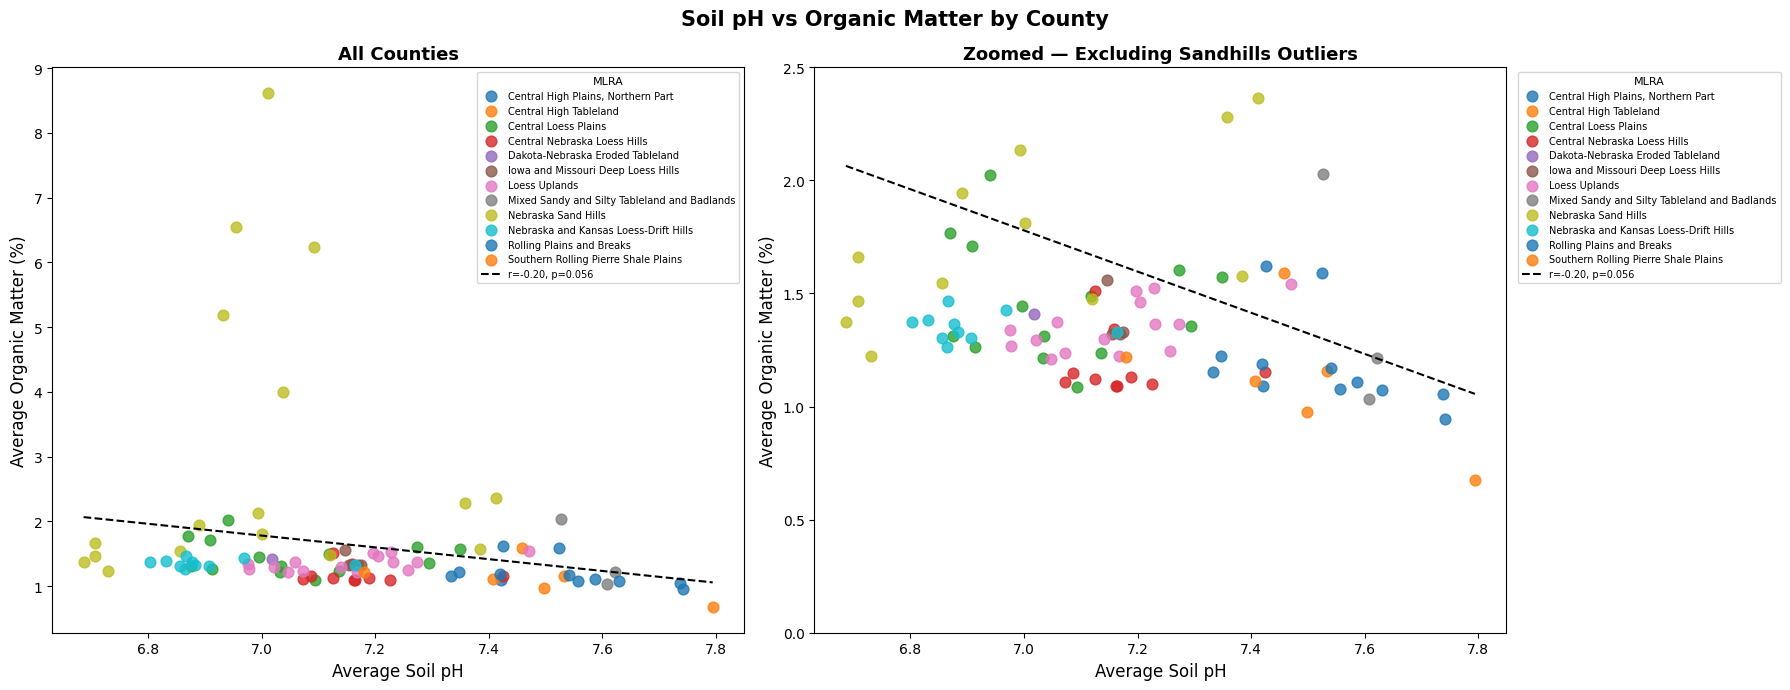

In [19]:
from scipy import stats
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Full plot
for mlra_name, group in dominant_mlra.groupby('MLRA_NAME'):
    ax1.scatter(group['avg_ph'], group['avg_om'], label=mlra_name, s=60, alpha=0.8)

ax1.set_xlabel('Average Soil pH', fontsize=12)
ax1.set_ylabel('Average Organic Matter (%)', fontsize=12)
ax1.set_title('All Counties', fontsize=13, fontweight='bold')
ax1.legend(fontsize=7, loc='upper right', title='MLRA', title_fontsize=8)

# Zoomed plot
for mlra_name, group in dominant_mlra.groupby('MLRA_NAME'):
    ax2.scatter(group['avg_ph'], group['avg_om'], label=mlra_name, s=60, alpha=0.8)

ax2.set_xlabel('Average Soil pH', fontsize=12)
ax2.set_ylabel('Average Organic Matter (%)', fontsize=12)
ax2.set_title('Zoomed — Excluding Sandhills Outliers', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 2.5)
ax2.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1), title='MLRA', title_fontsize=8, frameon=True)

fig.suptitle('Soil pH vs Organic Matter by County', fontsize=15, fontweight='bold')

# Calculate regression line
slope, intercept, r, p, se = stats.linregress(dominant_mlra['avg_ph'], dominant_mlra['avg_om'])

# Add regression line to both plots
clean = dominant_mlra[['avg_ph', 'avg_om']].dropna()
slope, intercept, r, p, se = stats.linregress(clean['avg_ph'], clean['avg_om'])
x_line = np.linspace(clean['avg_ph'].min(), clean['avg_ph'].max(), 100)
y_line = slope * x_line + intercept

ax1.plot(x_line, y_line, color='black', linewidth=1.5, linestyle='--', label=f'r={r:.2f}, p={p:.3f}')
ax1.legend(fontsize=7, loc='upper right', title='MLRA', title_fontsize=8)

ax2.plot(x_line, y_line, color='black', linewidth=1.5, linestyle='--', label=f'r={r:.2f}, p={p:.3f}')
ax2.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1), title='MLRA', title_fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig('nebraska_ph_om_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 18. Linear Regression Output
OLS linear regression of organic matter on soil pH. The model produces a slope of -0.91 and an R² of 0.04, meaning pH explains only about 4% of the variance in organic matter at the county level. The p-value (0.056) mirrors the Pearson result — borderline significant. Spatial autocorrelation (quantified in the next section) likely inflates the effective sample size, making these significance values optimistic.

In [20]:
import statsmodels.api as sm

X = sm.add_constant(dominant_mlra['avg_ph'].dropna())
y = dominant_mlra.loc[dominant_mlra['avg_ph'].notna(), 'avg_om']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 avg_om   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     3.742
Date:                Sun, 10 May 2026   Prob (F-statistic):             0.0562
Time:                        13:54:18   Log-Likelihood:                -142.97
No. Observations:                  92   AIC:                             289.9
Df Residuals:                      90   BIC:                             295.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1507      3.374      2.415      0.0

## 19. Moran's I for pH
Moran's I is a measure of spatial autocorrelation — it tests whether nearby locations tend to have similar values. A value near +1 indicates strong clustering, near 0 indicates randomness, and near -1 indicates dispersion. Nebraska soil pH shows a Moran's I of 0.78 (p = 0.001), indicating strong spatial clustering: high-pH counties are concentrated in the west and low-pH counties in the east, rather than being randomly distributed across the state.

In [21]:
from libpysal.weights import Queen
from esda.moran import Moran

# Need the spatial dataframe with pH values — reproject to match
nebraska_ph_proj = nebraska_combined.to_crs('EPSG:32614')

# Drop the county with missing pH
nebraska_ph_clean = nebraska_ph_proj.dropna(subset=['avg_ph'])

# Build spatial weights matrix (Queen contiguity - shared border or corner)
w = Queen.from_dataframe(nebraska_ph_clean, use_index=True)
w.transform = 'r'  # Row standardize

# Run Moran's I for pH
moran_ph = Moran(nebraska_ph_clean['avg_ph'], w)

print("Moran's I — Soil pH")
print(f"  I statistic:  {moran_ph.I:.4f}")
print(f"  p-value:      {moran_ph.p_sim:.4f}")
print(f"  z-score:      {moran_ph.z_sim:.4f}")

Moran's I — Soil pH
  I statistic:  0.7804
  p-value:      0.0010
  z-score:      12.6311


## 20. Moran's I For Organic Matter
Moran's I for organic matter is 0.55 (p = 0.001) — also strongly clustered, though less so than pH. The Sandhills region drives much of this clustering, with a contiguous group of high-OM counties in central Nebraska surrounded by lower-OM agricultural counties. The presence of strong spatial autocorrelation in both variables means standard regression significance tests are likely anti-conservative.

In [22]:
# Run Moran's I for organic matter
nebraska_om_clean = nebraska_ph_proj.dropna(subset=['avg_om'])
w_om = Queen.from_dataframe(nebraska_om_clean, use_index=True)
w_om.transform = 'r'

moran_om = Moran(nebraska_om_clean['avg_om'], w_om)

print("Moran's I — Organic Matter")
print(f"  I statistic:  {moran_om.I:.4f}")
print(f"  p-value:      {moran_om.p_sim:.4f}")
print(f"  z-score:      {moran_om.z_sim:.4f}")

Moran's I — Organic Matter
  I statistic:  0.5489
  p-value:      0.0010
  z-score:      9.9396


## 21. One-way ANOVA to check if pHs in MLRAs are significantly different
One-way ANOVA tests whether mean soil pH (and separately, organic matter) differs significantly across MLRA groups. Results: pH F = 15.8 (p < 0.001), OM F = 3.6 (p = 0.0003) — both are highly significant, confirming that MLRA membership explains a meaningful portion of variance in both soil properties. ANOVA tells us that *some* groups differ, but not which ones — that's addressed by the Tukey HSD post-hoc test below.

In [23]:
from scipy import stats

# Group counties by MLRA
mlra_groups_ph = [group['avg_ph'].dropna().values for name, group in dominant_mlra.groupby('MLRA_NAME')]
mlra_groups_om = [group['avg_om'].dropna().values for name, group in dominant_mlra.groupby('MLRA_NAME')]

# One-way ANOVA
f_stat_ph, p_val_ph = stats.f_oneway(*mlra_groups_ph)
f_stat_om, p_val_om = stats.f_oneway(*mlra_groups_om)

print("One-Way ANOVA — Soil pH by MLRA")
print(f"  F-statistic: {f_stat_ph:.3f}")
print(f"  p-value:     {p_val_ph:.6f}")

print(f"\nOne-Way ANOVA — Organic Matter by MLRA")
print(f"  F-statistic: {f_stat_om:.3f}")
print(f"  p-value:     {p_val_om:.6f}")

One-Way ANOVA — Soil pH by MLRA
  F-statistic: 15.786
  p-value:     0.000000

One-Way ANOVA — Organic Matter by MLRA
  F-statistic: 3.636
  p-value:     0.000339


## 22. Tukey's HSD Post-Hoc Test
Tukey's Honest Significant Difference (HSD) test performs all pairwise MLRA comparisons while controlling the family-wise error rate — accounting for the inflated false positive risk that comes with multiple simultaneous comparisons. This is the appropriate follow-up to a significant ANOVA result.

In [24]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD for pH
tukey_ph = pairwise_tukeyhsd(
    endog=dominant_mlra['avg_ph'].dropna(),
    groups=dominant_mlra.loc[dominant_mlra['avg_ph'].notna(), 'MLRA_NAME'],
    alpha=0.05
)

# Tukey HSD for organic matter
tukey_om = pairwise_tukeyhsd(
    endog=dominant_mlra['avg_om'].dropna(),
    groups=dominant_mlra.loc[dominant_mlra['avg_om'].notna(), 'MLRA_NAME'],
    alpha=0.05
)

print("Tukey HSD complete for both pH and organic matter.")

Tukey HSD complete for both pH and organic matter.


## 23. Significant MLRA Pairwise Differences
Filters Tukey HSD results to show only statistically significant pairwise differences (adjusted p < 0.05). For pH, 26 significant pairs were identified — consistent with the strong east-west gradient. For organic matter, 6 significant pairs were found, all involving the Nebraska Sandhills MLRAs. Outside the Sandhills, OM differences between MLRAs are largely not statistically significant at the county level.

In [25]:
# Significant pH pairs
tukey_ph_df = pd.DataFrame(data=tukey_ph._results_table.data[1:],
                            columns=tukey_ph._results_table.data[0])
significant_ph = tukey_ph_df[tukey_ph_df['reject'] == True]

print(f"=== Significant Soil pH Differences Between MLRAs ({len(significant_ph)} pairs) ===")
print(significant_ph[['group1', 'group2', 'meandiff', 'p-adj']].to_string(index=False))

# Significant OM pairs
tukey_om_df = pd.DataFrame(data=tukey_om._results_table.data[1:],
                            columns=tukey_om._results_table.data[0])
significant_om = tukey_om_df[tukey_om_df['reject'] == True]

print(f"\n=== Significant Organic Matter Differences Between MLRAs ({len(significant_om)} pairs) ===")
print(significant_om[['group1', 'group2', 'meandiff', 'p-adj']].to_string(index=False))

=== Significant Soil pH Differences Between MLRAs (26 pairs) ===
                                      group1                                       group2  meandiff  p-adj
          Central High Plains, Northern Part                         Central Loess Plains   -0.5012 0.0000
          Central High Plains, Northern Part                 Central Nebraska Loess Hills   -0.3872 0.0033
          Central High Plains, Northern Part           Iowa and Missouri Deep Loess Hills   -0.3995 0.0215
          Central High Plains, Northern Part                                Loess Uplands   -0.4060 0.0007
          Central High Plains, Northern Part                          Nebraska Sand Hills   -0.5682 0.0000
          Central High Plains, Northern Part        Nebraska and Kansas Loess-Drift Hills   -0.6586 0.0000
                      Central High Tableland                         Central Loess Plains   -0.4786 0.0000
                      Central High Tableland                 Central Nebraska L

## 24. Load and Filter NCSS Pedon Sampling Sites
Loads NCSS (National Cooperative Soil Survey) pedon sampling site locations from a local GeoJSON file exported in a prior step. These are physical soil sampling points maintained in the USDA lab database. Filtering retains only sites within Nebraska, resulting in 2,305 georeferenced sampling locations. Site distribution across counties is a proxy for data quality — counties with few or no sites rely on extrapolated soil series correlations rather than direct measurements.

In [26]:
# Load site layer and filter to Nebraska
# Load from local GeoJSON (exported from NCSS GeoPackage)
# Original source: https://ncsslabdatamart.sc.egov.usda.gov/database_download.aspx
try:
    ne_sites_clipped = gpd.read_file('ne_sampling_sites.geojson')
    print(f"Loaded {len(ne_sites_clipped)} Nebraska sampling sites")
except:
    print("GeoJSON not found - run export cell first or download from NCSS Lab Data Mart")

# ne_sites = lab_site[
#     (lab_site['latitude_std_decimal_degrees'] >= 40.0) &
#     (lab_site['latitude_std_decimal_degrees'] <= 43.0) &
#     (lab_site['longitude_std_decimal_degrees'] >= -104.0) &
#     (lab_site['longitude_std_decimal_degrees'] <= -95.3)
# ].copy()

# ne_sites_gdf = gpd.GeoDataFrame(
#     ne_sites,
#     geometry=gpd.points_from_xy(
#         ne_sites['longitude_std_decimal_degrees'],
#         ne_sites['latitude_std_decimal_degrees']
#     ),
#     crs='EPSG:4326'
# )

# ne_sites_clipped = gpd.clip(ne_sites_gdf, nebraska_boundary)
# print(f"Sites within Nebraska boundary: {len(ne_sites_clipped)}")

Loaded 2305 Nebraska sampling sites


## Export sampling sites to GeoJSON - Ran once
One-time export of NCSS pedon site data to a local GeoJSON file, commented out after initial use. The exported file (`ne_sampling_sites.geojson`) is committed to the repository so the notebook loads correctly for anyone cloning the repo without access to the original GeoPackage.

In [27]:
# Run once to export Nebraska sampling sites to GeoJSON
# After running, the try/except loader in the cell above will use this file
# ne_sites_clipped.to_file('ne_sampling_sites.geojson', driver='GeoJSON')
# print("Saved ne_sampling_sites.geojson")

## 25. NCSS Sampling Site Map
Point map showing the locations of all 2,305 NCSS pedon sampling sites within Nebraska. Site density varies considerably across the state — the eastern counties and areas near university research stations show denser coverage, while several western counties have few or no sites.

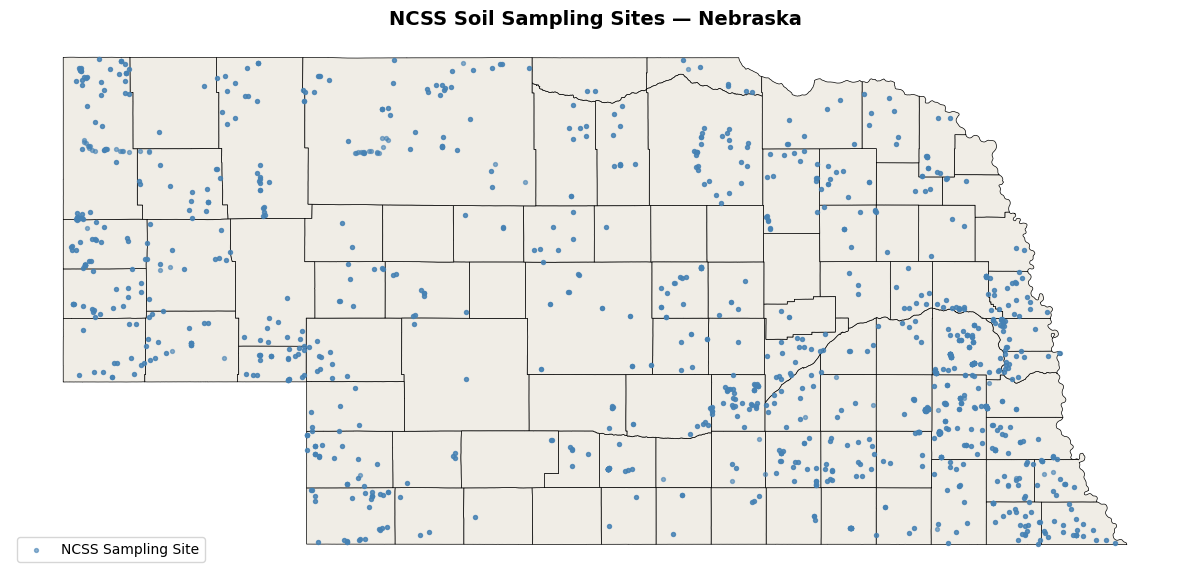

In [28]:
# Plot sampling sites over county boundaries
fig, ax = plt.subplots(figsize=(12, 6))

nebraska.to_crs('EPSG:4326').plot(
    ax=ax,
    facecolor='#f0ede6',
    edgecolor='black',
    linewidth=0.5
)

ne_sites_clipped.plot(
    ax=ax,
    color='steelblue',
    markersize=8,
    alpha=0.6,
    label='NCSS Sampling Site'
)

ax.set_title('NCSS Soil Sampling Sites — Nebraska', fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig('nebraska_sampling_sites.png', dpi=300, bbox_inches='tight')
plt.show()

## 26. Calculate Site Counts per County
Aggregates pedon sampling sites to the county level by performing a spatial join between site points and county polygons. The resulting count per county is used to classify data adequacy in the next cell. Seven counties returned zero sites.

In [29]:
# Count NCSS sites per county and classify coverage tiers
sites_per_county = gpd.sjoin(ne_sites_clipped, nebraska.to_crs('EPSG:4326'), how='left', predicate='within')
county_site_counts = sites_per_county.groupby('NAME').size().reset_index(name='site_count')

nebraska_counts = nebraska.to_crs('EPSG:4326').merge(county_site_counts, on='NAME', how='left')
nebraska_counts['site_count'] = nebraska_counts['site_count'].fillna(0).astype(int)

print(f"Counties with site counts: {len(nebraska_counts)}")
print(f"Counties with 0 sites: {len(nebraska_counts[nebraska_counts['site_count'] == 0])}")

Counties with site counts: 93
Counties with 0 sites: 7


## 27. Labelled Chloropleth Map of NCSS Sampling Sites
Three-panel choropleth map classifying counties by sampling density: sparse (≤ 5 sites), marginal (6–10 sites), and adequate (> 10 sites). Counties with sparse or zero coverage are flagged as data limitations — their pH and OM values in this analysis are derived from soil series correlation models rather than direct pedon measurements, and should be interpreted with greater uncertainty.

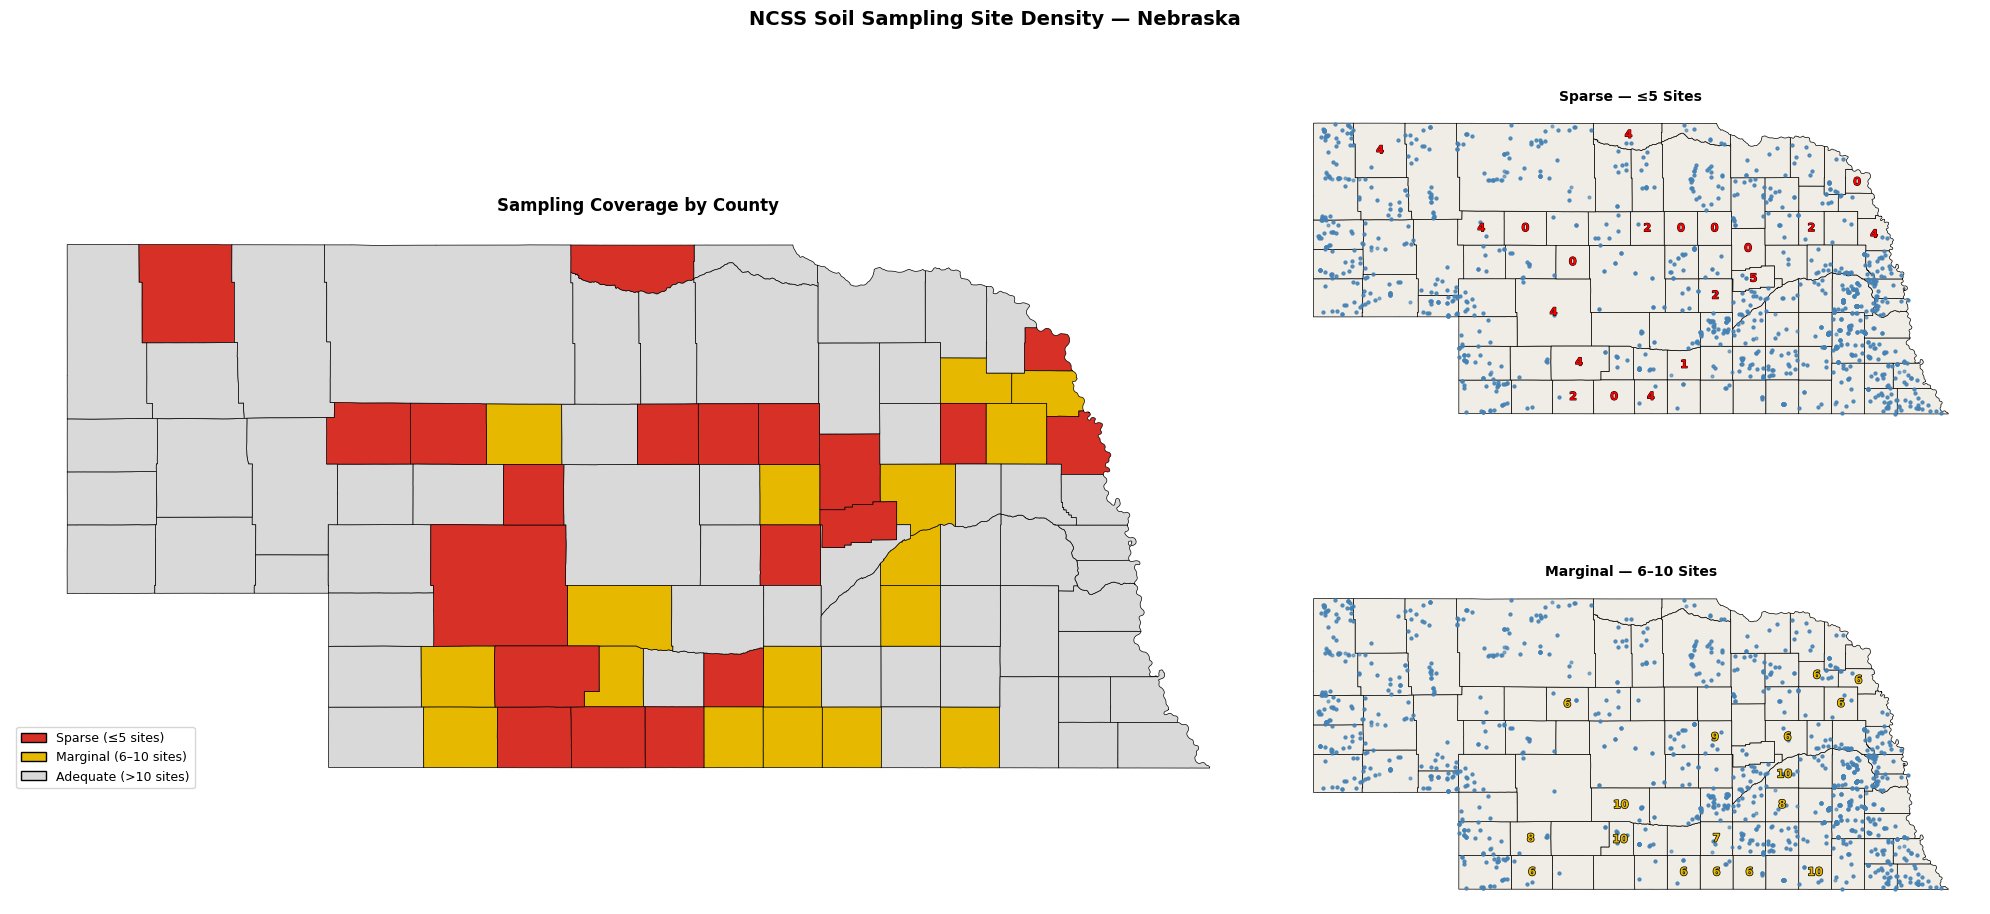

In [30]:
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.8, 1])

ax1 = fig.add_subplot(gs[:, 0])   # Left - full height
ax2 = fig.add_subplot(gs[0, 1])   # Top right
ax3 = fig.add_subplot(gs[1, 1])   # Bottom right

# Classify counties
def coverage_tier(count):
    if count <= 5:
        return 'Sparse (≤5)'
    elif count <= 10:
        return 'Marginal (6–10)'
    else:
        return 'Adequate (>10)'

nebraska_counts['coverage'] = nebraska_counts['site_count'].apply(coverage_tier)

color_map = {
    'Sparse (≤5)': '#d73027',
    'Marginal (6–10)': '#e6b800',
    'Adequate (>10)': '#d9d9d9'
}

nebraska_counts['color'] = nebraska_counts['coverage'].map(color_map)

# Panel 1 - Summary choropleth
nebraska_counts.plot(ax=ax1, color=nebraska_counts['color'], edgecolor='black', linewidth=0.5)
ax1.set_title('Sampling Coverage by County', fontsize=12, fontweight='bold')
ax1.set_axis_off()

legend_elements = [
    Patch(facecolor='#d73027', edgecolor='black', label='Sparse (≤5 sites)'),
    Patch(facecolor='#e6b800', edgecolor='black', label='Marginal (6–10 sites)'),
    Patch(facecolor='#d9d9d9', edgecolor='black', label='Adequate (>10 sites)')
]
ax1.legend(handles=legend_elements, fontsize=9, loc='lower left')

# Panel 2 - Sparse
nebraska_counts.plot(ax=ax2, facecolor='#f0ede6', edgecolor='black', linewidth=0.5)
ne_sites_clipped.plot(ax=ax2, color='steelblue', markersize=4, alpha=0.6)
sparse = nebraska_counts[nebraska_counts['site_count'] <= 5]
for _, row in sparse.iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(str(row['site_count']), xy=(centroid.x, centroid.y),
                fontsize=8, color='red', ha='center', va='center', fontweight='bold', path_effects=[pe.withStroke(linewidth=.75, foreground='black')])
ax2.set_title('Sparse — ≤5 Sites', fontsize=10, fontweight='bold')
ax2.set_axis_off()

# Panel 3 - Marginal
nebraska_counts.plot(ax=ax3, facecolor='#f0ede6', edgecolor='black', linewidth=0.5)
ne_sites_clipped.plot(ax=ax3, color='steelblue', markersize=4, alpha=0.6)
marginal = nebraska_counts[(nebraska_counts['site_count'] >= 6) & (nebraska_counts['site_count'] <= 10)]
for _, row in marginal.iterrows():
    centroid = row.geometry.centroid
    ax3.annotate(str(row['site_count']), xy=(centroid.x, centroid.y),
                fontsize=8, color='#e6b800', ha='center', va='center', fontweight='bold',
                path_effects=[pe.withStroke(linewidth=1, foreground='black')])
ax3.set_title('Marginal — 6–10 Sites', fontsize=10, fontweight='bold')
ax3.set_axis_off()

fig.suptitle('NCSS Soil Sampling Site Density — Nebraska', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nebraska_sampling_sites.png', dpi=300, bbox_inches='tight')
plt.show()

## 28. Interactive pH Chloropleth Map Folium Map
Interactive choropleth map built with Folium, saved as a standalone HTML file and published separately. The map displays weighted average soil pH as a filled choropleth using the same RdYlGn color scale as the static map. Hover tooltips show county name, average pH, and average organic matter for each county. A layer control is included for toggling the tooltip overlay independently.

In [31]:
import folium
import json

nebraska_folium = nebraska_combined.to_crs('EPSG:4326')

m = folium.Map(location=[41.5, -99.9], zoom_start=7, tiles='CartoDB positron')

ph_choropleth = folium.Choropleth(
    geo_data=nebraska_folium.to_json(),
    name='Soil pH',
    data=nebraska_folium,
    columns=['county', 'avg_ph'],
    key_on='feature.properties.county',
    fill_color='RdYlGn_r',
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name='Average Soil pH',
    nan_fill_color='lightgrey',
    smooth_factor=0
).add_to(m)

ph_choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields=['county', 'avg_ph', 'avg_om'],
        aliases=['County', 'Avg pH', 'Avg Organic Matter (%)'],
        localize=True,
        sticky=True
    )
)

om_choropleth = folium.Choropleth(
    geo_data=nebraska_folium.to_json(),
    name='Organic Matter (%)',
    data=nebraska_folium,
    columns=['county', 'avg_om'],
    key_on='feature.properties.county',
    fill_color='YlGn',
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name='Average Organic Matter (%)',
    nan_fill_color='lightgrey',
    show=False,
    smooth_factor=0
).add_to(m)

om_choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields=['county', 'avg_ph', 'avg_om'],
        aliases=['County', 'Avg pH', 'Avg Organic Matter (%)'],
        localize=True,
        sticky=True
    )
)

folium.LayerControl().add_to(m)

m.get_root().html.add_child(folium.Element("""
    <style>
    .leaflet-top.leaflet-right .leaflet-control-zoom { display: none; }
    </style>
    <script>
    window.addEventListener('load', function() {
        setTimeout(function() {
            var maps = Object.values(window).filter(v => v && v._leaflet_id && v.zoomControl);
            if (maps.length) maps[0].zoomControl.setPosition('bottomleft');
        }, 500);
    });
    </script>
"""))

m.save('nebraska_soil_interactive.html')
print("Saved nebraska_soil_interactive.html")

Saved nebraska_soil_interactive.html
